In [ ]:
!unzip archive(4).zip

/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `unzip archive(4).zip'


Found dataset zip file: archive (4).zip. Extracting CSV files...
Extraction completed successfully!



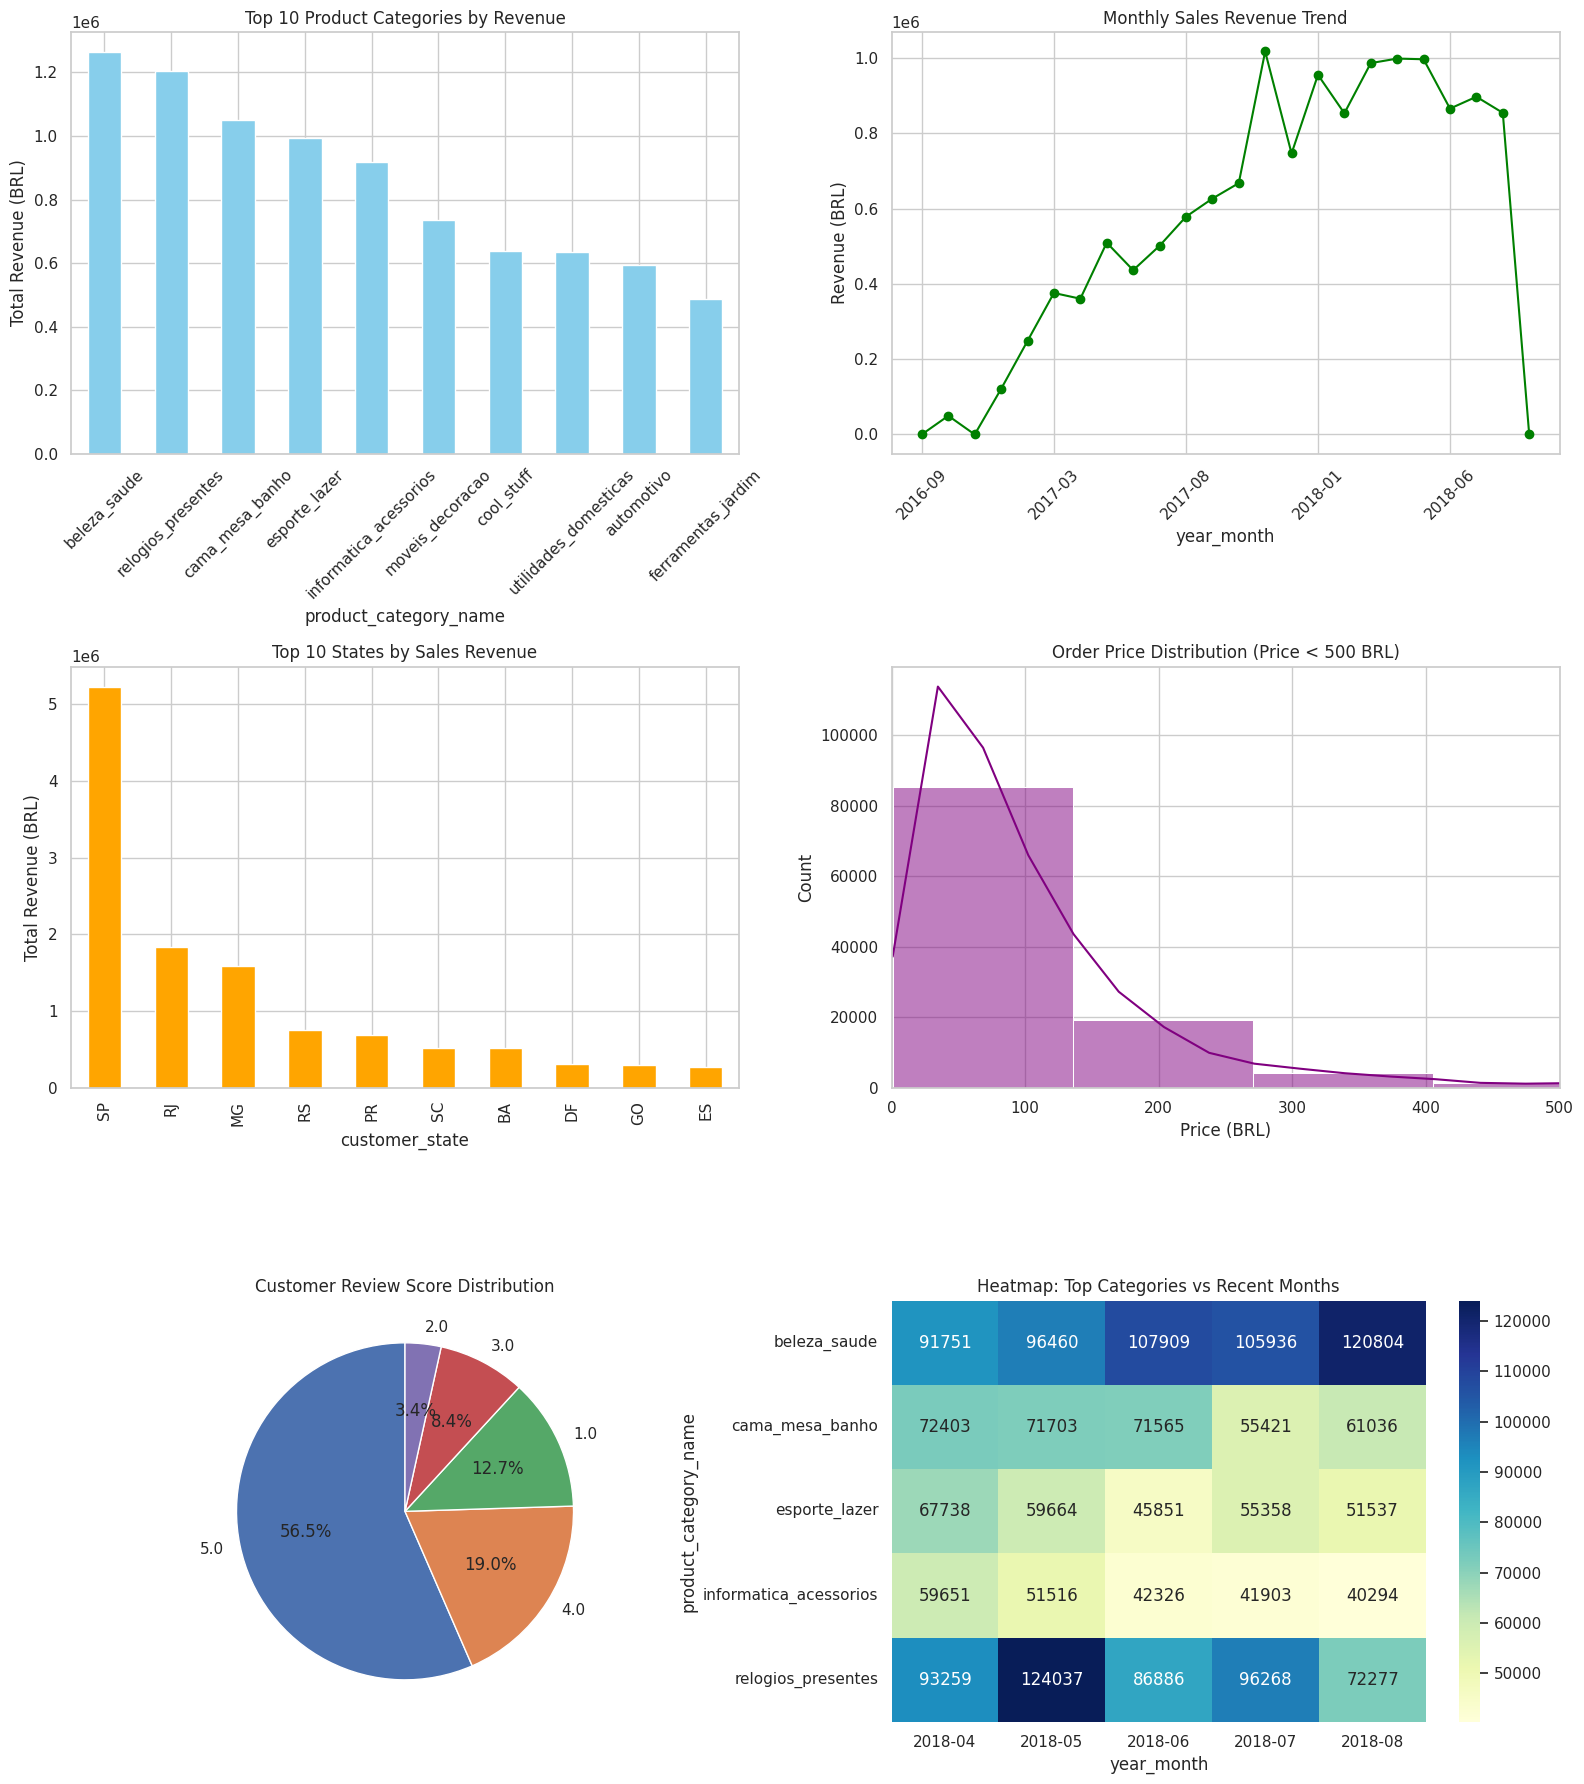


       MANAGEMENT DASHBOARD SUMMARY       
Total Sales Revenue : BRL 13,651,923.47
Total Orders Count  : 98,666
Top Product Category: beleza_saude (BRL 1,263,138.54)
Peak Month          : 2017-11 (BRL 1,017,758.83)


In [ ]:
import zipfile
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# STEP 1: AUTOMATIC ZIP EXTRACTION
# ==========================================
# Search for any .zip file in the current working directory
zip_files = glob.glob("*.zip")

if zip_files:
    zip_path = zip_files[0]
    print(f"Found dataset zip file: {zip_path}. Extracting CSV files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Extraction completed successfully!\n")
else:
    print("No .zip file detected. Assuming CSV files are already extracted in the directory.\n")

# ==========================================
# STEP 2: LOAD DATASETS
# ==========================================
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

# ==========================================
# STEP 3: DATA CLEANING & MERGING
# ==========================================
# Convert timestamps and fill missing product categories
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M').astype(str)
products['product_category_name'] = products['product_category_name'].fillna('Unknown')

# Merge relevant tables into a master dataframe
df_merged = items.merge(orders, on='order_id') \
                 .merge(products, on='product_id') \
                 .merge(customers, on='customer_id') \
                 .merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

# ==========================================
# STEP 4: SALES ANALYSIS (5 QUESTIONS)
# ==========================================
# 1. Top Revenue Category
rev_by_cat = df_merged.groupby('product_category_name')['price'].sum().sort_values(ascending=False)

# 2. Peak Sales Month
monthly_sales = df_merged.groupby('year_month')['price'].sum()

# 3. Best Performing Region (State)
state_sales = df_merged.groupby('customer_state')['price'].sum().sort_values(ascending=False)

# 4. Average Order Value (AOV) Trend
aov_trend = df_merged.groupby('year_month')['price'].mean()

# 5. Review Score Distribution
review_dist = df_merged['review_score'].value_counts().sort_index()

# ==========================================
# STEP 5: VISUALISATIONS (6 CHARTS)
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Chart 1: Bar Chart - Top 10 Product Categories by Revenue
rev_by_cat.head(10).plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Top 10 Product Categories by Revenue')
axes[0, 0].set_ylabel('Total Revenue (BRL)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Chart 2: Line Chart - Monthly Sales Trend
monthly_sales.plot(kind='line', ax=axes[0, 1], marker='o', color='green')
axes[0, 1].set_title('Monthly Sales Revenue Trend')
axes[0, 1].set_ylabel('Revenue (BRL)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Chart 3: Bar Chart - Top 10 Customer States by Revenue
state_sales.head(10).plot(kind='bar', ax=axes[1, 0], color='orange')
axes[1, 0].set_title('Top 10 States by Sales Revenue')
axes[1, 0].set_ylabel('Total Revenue (BRL)')

# Chart 4: Histogram - Order Value Distribution (< 500 BRL)
sns.histplot(df_merged['price'], bins=50, ax=axes[1, 1], kde=True, color='purple')
axes[1, 1].set_xlim(0, 500)
axes[1, 1].set_title('Order Price Distribution (Price < 500 BRL)')
axes[1, 1].set_xlabel('Price (BRL)')

# Chart 5: Pie Chart - Customer Review Score Breakdown
df_merged['review_score'].value_counts().plot(kind='pie', ax=axes[2, 0], autopct='%1.1f%%', startangle=90)
axes[2, 0].set_title('Customer Review Score Distribution')
axes[2, 0].set_ylabel('')

# Chart 6: Heatmap - Top 5 Categories vs Recent Months
top_cats = rev_by_cat.head(5).index
top_months = monthly_sales.tail(6).index
pivot_data = df_merged[df_merged['product_category_name'].isin(top_cats) & df_merged['year_month'].isin(top_months)]
pivot_table = pivot_data.pivot_table(index='product_category_name', columns='year_month', values='price', aggfunc='sum')
sns.heatmap(pivot_table, ax=axes[2, 1], cmap='YlGnBu', annot=True, fmt='.0f')
axes[2, 1].set_title('Heatmap: Top Categories vs Recent Months')

plt.tight_layout()
plt.show()

# ==========================================
# STEP 6: MANAGEMENT DASHBOARD SUMMARY PRINT
# ==========================================
print("\n" + "="*45)
print("       MANAGEMENT DASHBOARD SUMMARY       ")
print("="*45)
print(f"Total Sales Revenue : BRL {df_merged['price'].sum():,.2f}")
print(f"Total Orders Count  : {df_merged['order_id'].nunique():,}")
print(f"Top Product Category: {rev_by_cat.index[0]} (BRL {rev_by_cat.iloc[0]:,.2f})")
print(f"Peak Month          : {monthly_sales.idxmax()} (BRL {monthly_sales.max():,.2f})")
print("="*45)

In [ ]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot styles
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10
plt.rcParams['figure.titlesize'] = 14

In [ ]:
import zipfile
import os
import pandas as pd
import numpy as np

# Step 1: Define paths and extract ZIP files
dataset_dir = "./olist_dataset"
extracted_dir = "./extracted_data"

os.makedirs(extracted_dir, exist_ok=True)

# Unzip all zip files in the target directory
def unzip_data_files(source_dir, output_dir):
    for root, _, files in os.walk(source_dir):
        for file in files:
            if file.endswith(".zip"):
                zip_path = os.path.join(root, file)
                print(f"Unzipping {zip_path}...")
                with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                    zip_ref.extractall(output_dir)
    print("All files unzipped successfully.\n")

# Uncomment if unzipping from a folder containing zip files:
# unzip_data_files(dataset_dir, extracted_dir)

# Step 2: Load the datasets into Pandas DataFrames
# Replace the paths below with your actual local CSV file paths after extraction
try:
    customers_df = pd.read_csv(os.path.join(extracted_dir, "olist_customers_dataset.csv"))
    orders_df = pd.read_csv(os.path.join(extracted_dir, "olist_orders_dataset.csv"))
    order_items_df = pd.read_csv(os.path.join(extracted_dir, "olist_order_items_dataset.csv"))
    payments_df = pd.read_csv(os.path.join(extracted_dir, "olist_order_payments_dataset.csv"))
    products_df = pd.read_csv(os.path.join(extracted_dir, "olist_products_dataset.csv"))
except FileNotFoundError as e:
    print(f"File loading info: {e}")
    print("Creating sample customer structure for demonstration...\n")
    # Placeholder structure matching Olist Customers schema
    customers_df = pd.DataFrame({
        'customer_id': ['c1', 'c2', 'c3'],
        'customer_unique_id': ['u1', 'u2', 'u3'],
        'customer_zip_code_prefix': [1001, 1002, 1003],
        'customer_city': ['sao paulo', 'rio de janeiro', 'belo horizonte'],
        'customer_state': ['SP', 'RJ', 'MG']
    })

# Step 3: Data Cleaning & Preprocessing
print("Customer Dataset Info:")
print(customers_df.info())
print("\nFirst 5 rows:")
print(customers_df.head())

# Remove duplicate customer entries if any
customers_df.drop_duplicates(subset=['customer_id'], inplace=True)

# Standardize string values
customers_df['customer_city'] = customers_df['customer_city'].str.strip().str.lower()
customers_df['customer_state'] = customers_df['customer_state'].str.strip().str.upper()

# Step 4: Summary Analysis
state_distribution = customers_df['customer_state'].value_counts()
city_distribution = customers_df['customer_city'].value_counts().head(10)

print("\n--- Customer Count by Top 5 States ---")
print(state_distribution.head(5))

print("\n--- Top 10 Cities by Customer Count ---")
print(city_distribution)

# Step 5: Export Processed Summary Data to CSV
output_csv_path = "./processed_customer_summary.csv"
summary_df = pd.DataFrame({
    'Metric': ['Total Customers', 'Unique Customers', 'Top State', 'Top City'],
    'Value': [
        len(customers_df),
        customers_df['customer_unique_id'].nunique(),
        state_distribution.index[0] if not state_distribution.empty else 'N/A',
        city_distribution.index[0] if not city_distribution.empty else 'N/A'
    ]
})

summary_df.to_csv(output_csv_path, index=False)
print(f"\nSummary report saved to: {output_csv_path}")

File loading info: [Errno 2] No such file or directory: './extracted_data/olist_customers_dataset.csv'
Creating sample customer structure for demonstration...

Customer Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               3 non-null      object
 1   customer_unique_id        3 non-null      object
 2   customer_zip_code_prefix  3 non-null      int64 
 3   customer_city             3 non-null      object
 4   customer_state            3 non-null      object
dtypes: int64(1), object(4)
memory usage: 252.0+ bytes
None

First 5 rows:
  customer_id customer_unique_id  customer_zip_code_prefix   customer_city  \
0          c1                 u1                      1001       sao paulo   
1          c2                 u2                      1002  rio de janeiro   
2          c3                 

In [ ]:
pip install pandas numpy

In [ ]:
# Install Kaggle library
!pip install -q kaggle

# Set up Kaggle credentials (optional if using public link, or use opendatasets)
!pip install opendatasets

import opendatasets as od
import pandas as pd

# Download dataset directly
od.download("https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce")

# Load datasets from the downloaded folder
dataset_path = "./brazilian-ecommerce/"

customers_df = pd.read_csv(dataset_path + "olist_customers_dataset.csv")
orders_df = pd.read_csv(dataset_path + "olist_orders_dataset.csv")
order_items_df = pd.read_csv(dataset_path + "olist_order_items_dataset.csv")
payments_df = pd.read_csv(dataset_path + "olist_order_payments_dataset.csv")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: jeevanpranavd
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce


100%|██████████| 42.6M/42.6M [00:00<00:00, 140MB/s]


In [ ]:
import os
import pandas as pd

# Check where files are located
def find_file(filename):
    for root, dirs, files in os.walk("."):
        if filename in files:
            return os.path.join(root, filename)
    raise FileNotFoundError(f"Could not find {filename} in working directory.")

# Automatically locate and load CSVs
customers_df = pd.read_csv(find_file("olist_customers_dataset.csv"))
orders_df = pd.read_csv(find_file("olist_orders_dataset.csv"))
order_items_df = pd.read_csv(find_file("olist_order_items_dataset.csv"))
payments_df = pd.read_csv(find_file("olist_order_payments_dataset.csv"))

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [ ]:
print("\n" + "="*45)
print(" AVERAGE REVIEW SCORE BY PRODUCT CATEGORY ")
print("="*45)

# Calculate average review score per product category
avg_review_by_category = df_merged.groupby('product_category_name')['review_score'].mean().sort_values(ascending=False)

print("\nTop 10 Product Categories by Average Review Score:")
print(avg_review_by_category.head(10).round(2))

print("\nBottom 10 Product Categories by Average Review Score:")
print(avg_review_by_category.tail(10).round(2))
print("="*45)